<a href="https://colab.research.google.com/github/Thnh8052/Project-III/blob/main/P3Trainning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os
import shutil
from google.colab import files


# ==========================================
# 1. UPLOAD VÀ GIẢI NÉN CHÍNH XÁC
# ==========================================
print("Vui lòng upload file data.zip của bạn:")
uploaded = files.upload()

# Lấy chính xác tên file vừa upload (khắc phục lỗi data (1).zip)
zip_filename = list(uploaded.keys())[0]
extract_path = "/content/my_dataset"

print(f"\nĐang giải nén file '{zip_filename}'...")
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("✅ Giải nén xong!")

# ==========================================
# 2. TỰ ĐỘNG TÌM ĐƯỜNG DẪN TRAIN / TEST
# ==========================================
train_dir = ""
test_dir = ""

# Dùng os.walk để càn quét mọi ngóc ngách trong thư mục vừa giải nén
for root, dirs, files_in_dir in os.walk(extract_path):
    if 'train' in dirs:
        train_dir = os.path.join(root, 'train')
    if 'test' in dirs:
        test_dir = os.path.join(root, 'test')

# Kiểm tra kết quả
if train_dir and test_dir:
    print("\n🎉 TUYỆT VỜI! Đã tự động tìm thấy đường dẫn:")
    print("👉 Train dir :", train_dir)
    print("👉 Test dir  :", test_dir)

    # In thử số class để xác nhận
    try:
        print("Số class trong Train:", len(os.listdir(train_dir)))
    except:
        pass
else:
    print("\n❌ CẢNH BÁO: Vẫn không tìm thấy thư mục 'train' hoặc 'test' bên trong file zip.")
    print("Hãy kiểm tra lại cấu trúc file zip của bạn xem có chứa ảnh không nhé!")

Vui lòng upload file data.zip của bạn:


Saving data.zip to data.zip

Đang giải nén file 'data.zip'...
✅ Giải nén xong!

🎉 TUYỆT VỜI! Đã tự động tìm thấy đường dẫn:
👉 Train dir : /content/my_dataset/DATASET/train
👉 Test dir  : /content/my_dataset/DATASET/test
Số class trong Train: 7


In [ ]:
import glob
# 👉 THAY ĐỔI ĐƯỜNG DẪN CỦA BẠN VÀO ĐÂY:
train_dir = '/content/my_dataset/DATASET/train'
test_dir = '/content/my_dataset/DATASET/test'

def oversample_folder(folder_path, target_count):
    images = glob.glob(os.path.join(folder_path, '*.*'))
    current_count = len(images)
    print(f"Thư mục '{os.path.basename(folder_path)}' có: {current_count} ảnh.")

    if current_count >= target_count or current_count == 0:
        print("👉 Không cần nhân bản thêm.\n")
        return

    images_needed = target_count - current_count
    print(f"⏳ Đang nhân bản thêm {images_needed} ảnh...")

    for i in range(images_needed):
        src_image = images[i % current_count]
        filename, file_extension = os.path.splitext(os.path.basename(src_image))
        new_filename = f"{filename}_copy_{i}{file_extension}"
        dst_image = os.path.join(folder_path, new_filename)
        shutil.copy(src_image, dst_image)

    print(f"✅ Đã xong! Thư mục '{os.path.basename(folder_path)}' hiện có {len(glob.glob(os.path.join(folder_path, '*.*')))} ảnh.\n")

# Nhân bản Class 2 (Fear) và 3 (Disgust) lên 2000 ảnh để ngang bằng với các class khác
TARGET_IMAGES = 1800
print("--- OVERSAMPLING CLASS 2 (FEAR) ---")
oversample_folder(os.path.join(train_dir, '2'), TARGET_IMAGES)

print("--- OVERSAMPLING CLASS 3 (DISGUST) ---")
oversample_folder(os.path.join(train_dir, '3'), TARGET_IMAGES)

--- OVERSAMPLING CLASS 2 (FEAR) ---
Thư mục '2' có: 281 ảnh.
⏳ Đang nhân bản thêm 1519 ảnh...
✅ Đã xong! Thư mục '2' hiện có 1800 ảnh.

--- OVERSAMPLING CLASS 3 (DISGUST) ---
Thư mục '3' có: 717 ảnh.
⏳ Đang nhân bản thêm 1083 ảnh...
✅ Đã xong! Thư mục '3' hiện có 1800 ảnh.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import tensorflow as tf
from tensorflow import keras
from keras.preprocessing import image
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization,GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import cv2

# Cố định seed để kết quả ổn định
seed = random.randint(1, 1000)
print("Random Seed:", seed)

img_size = 100
targetx = 100
targety = 100
epochs = 85
batch_size = 64

Random Seed: 550


In [ ]:
# ==============================
# DATA GENERATOR
# ==============================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    fill_mode='nearest'
)

#TẠO RIÊNG DATAGEN CHO VALIDATION (Không Augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# ==============================
# TRAIN
# ==============================
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(targetx, targety),
    batch_size=batch_size,
    class_mode='categorical',
    subset="training",
    shuffle=True,
    seed=seed
)

# ==============================
# VALIDATION
# ==============================
val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=(targetx, targety),
    batch_size=batch_size,
    class_mode='categorical',
    subset="validation",
    shuffle=False,
    seed=seed
)

# ==============================
# TEST (độc lập hoàn toàn)
# ==============================
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(targetx, targety),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ==============================
# LABEL MAPPING
# ==============================
class_labels = train_generator.class_indices

rafdb_mapping = {
    '1': 'Surprise',
    '2': 'Fear',
    '3': 'Disgust',
    '4': 'Happy',
    '5': 'Sad',
    '6': 'Angry',
    '7': 'Neutral'
}

# map index → label
label_dict = {v: rafdb_mapping[k] for k, v in class_labels.items()}

print("Class indices:", class_labels)
print("Label dict:", label_dict)

Found 11900 images belonging to 7 classes.
Found 2973 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
Class indices: {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6}
Label dict: {0: 'Surprise', 1: 'Fear', 2: 'Disgust', 3: 'Happy', 4: 'Sad', 5: 'Angry', 6: 'Neutral'}


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import AdamW
import tensorflow as tf

inputs = Input(shape=(targetx, targety, 3))

# ==========================================
# KHỐI CNN 1
# ==========================================
x = Conv2D(32, kernel_size=(3, 3), padding='same', activation='elu')(inputs)
x = Conv2D(64, (3,3), padding='same', activation='elu')(x)
x = BatchNormalization()(x) # BN đặt SAU elu theo đúng ý bạn
x = MaxPool2D(pool_size=(2, 2))(x)
x = Dropout(0.3)(x)

# ==========================================
# KHỐI CNN 2
# ==========================================
x = Conv2D(128, (5,5), padding='same', activation='elu')(x)
x = BatchNormalization()(x)
x = MaxPool2D(pool_size=(2, 2))(x)
x = Dropout(0.35)(x)

# ==========================================
# KHỐI CNN 3
# ==========================================
x = Conv2D(512, (3,3), padding='same', activation='elu')(x)
x = BatchNormalization()(x)
x = MaxPool2D(pool_size=(2, 2))(x)
x = Dropout(0.4)(x)

# ==========================================
# KHỐI CNN 4
# ==========================================
x = Conv2D(512, (3,3), padding='same', activation='elu')(x)
x = BatchNormalization()(x)
x = MaxPool2D(pool_size=(2, 2))(x)
x = Dropout(0.4)(x)

# ==========================================
# 🔥 VŨ KHÍ TỐI THƯỢNG: HYBRID POOLING
# ==========================================
gap = GlobalAveragePooling2D()(x) # Lấy trung bình (Context)
gmp = GlobalMaxPooling2D()(x)     # Lấy cực đại (Micro-expressions)
x = Concatenate()([gap, gmp])     # Ép thành 1 siêu vector (1024 chiều)

# ==========================================
# LỚP FULLY CONNECTED
# ==========================================
x = Dense(512, activation='elu')(x)
x = BatchNormalization()(x)
x = Dropout(0.45)(x)

x = Dense(256, activation='elu')(x)
x = BatchNormalization()(x)
x = Dropout(0.45)(x)

outputs = Dense(7, activation='softmax')(x)

# Đóng gói Model
model = Model(inputs, outputs, name="CustomCNN_ELU_Hybrid")

# ==========================================
# COMPILE
# ==========================================
model.compile(
    # AdamW kết hợp tính năng chống overfit trực tiếp (đã bỏ L2 cũ)
    optimizer=AdamW(learning_rate=0.0005, weight_decay=1e-4),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

Model: "CustomCNN_ELU_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 100, 100,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 100, 100,  │     18,496 │ conv2d_15[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 100,  │        256 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 50, 50,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 50, 50,    │          0 │ max_pooling2d_12… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 50, 50,    │    204,928 │ dropout_18[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 50,    │        512 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 25, 25,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 25, 25,    │          0 │ max_pooling2d_13… │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 25, 25,    │    590,336 │ dropout_19[0][0]  │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 25,    │      2,048 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 12, 12,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 12, 12,    │          0 │ max_pooling2d_14… │
│ (Dropout)           │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 12, 12,    │  2,359,808 │ dropout_20[0][0]  │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 12,    │      2,048 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 6, 6, 512) │          0 │ batch_normalizat

 Total params: 3,840,327 (14.65 MB)

 Trainable params: 3,836,359 (14.63 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [ ]:
# ==========================================
# Callbacks
checkpoint = ModelCheckpoint(
    filepath='best_custom_cnn_emotion.keras',
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

callbacks_list =[checkpoint, reduce_lr, early_stop]

# Tiến hành Train
history = model.fit(
    x=train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=callbacks_list,
)

Epoch 1/85
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.2107 - loss: 2.5943
Epoch 1: val_accuracy improved from None to 0.32089, saving model to best_custom_cnn_emotion.keras

Epoch 1: finished saving model to best_custom_cnn_emotion.keras
186/186 ━━━━━━━━━━━━━━━━━━━━ 78s 349ms/step - accuracy: 0.2292 - loss: 2.4208 - val_accuracy: 0.3209 - val_loss: 2.4121 - learning_rate: 5.0000e-04
Epoch 2/85
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.2581 - loss: 2.1623
Epoch 2: val_accuracy did not improve from 0.32089
186/186 ━━━━━━━━━━━━━━━━━━━━ 54s 291ms/step - accuracy: 0.2712 - loss: 2.1164 - val_accuracy: 0.3209 - val_loss: 2.9469 - learning_rate: 5.0000e-04
Epoch 3/85
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.3005 - loss: 2.0112
Epoch 3: val_accuracy did not improve from 0.32089
186/186 ━━━━━━━━━━━━━━━━━━━━ 51s 275ms/step - accuracy: 0.3087 - loss: 1.9738 - val_accuracy: 0.3209 - val_loss: 2.7345 - learning_rate: 5.0000e-04
Epoch 4/85
186/186 ━━━━━━━

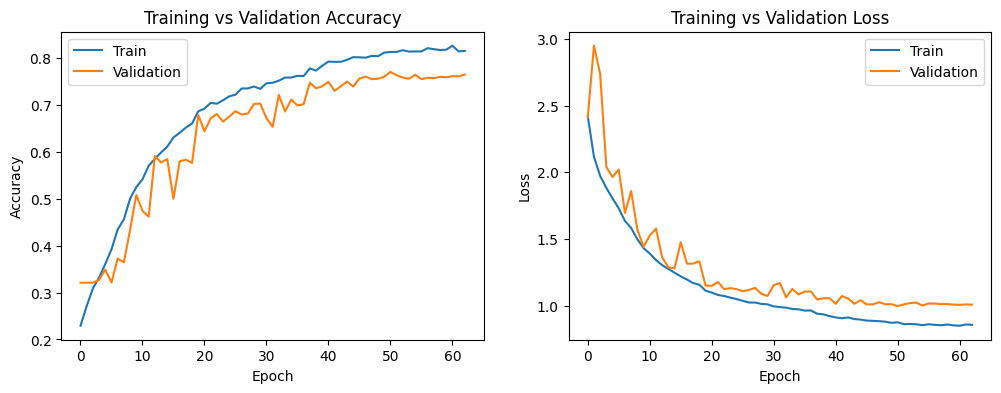

48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.8142 - loss: 0.8730
Final Test Accuracy = 81.42%


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Training vs Validation Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Training vs Validation Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper right')

plt.show()

# Đánh giá trên tập test
test_loss, test_acc = model.evaluate(test_generator)
print("Final Test Accuracy = {:.2f}%".format(test_acc * 100))

48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step


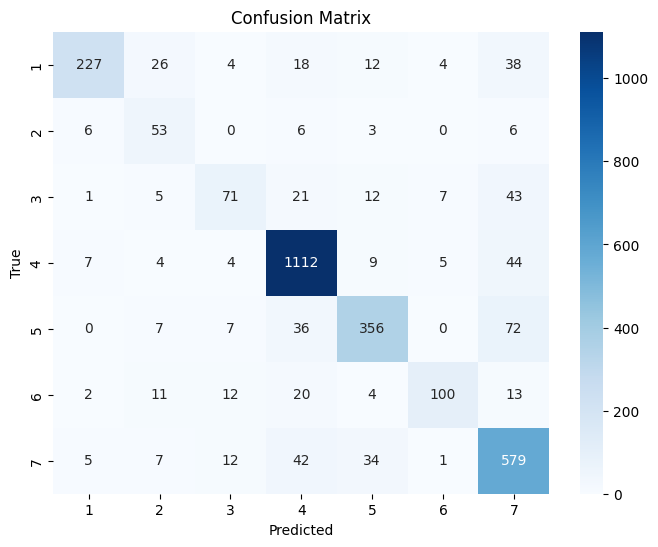


Classification Report:

              precision    recall  f1-score   support

           1       0.92      0.69      0.79       329
           2       0.47      0.72      0.57        74
           3       0.65      0.44      0.53       160
           4       0.89      0.94      0.91      1185
           5       0.83      0.74      0.78       478
           6       0.85      0.62      0.72       162
           7       0.73      0.85      0.79       680

    accuracy                           0.81      3068
   macro avg       0.76      0.71      0.73      3068
weighted avg       0.82      0.81      0.81      3068



In [ ]:
# ==============================
# CONFUSION MATRIX (Keras)
# ==============================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ==============================
# 1. DỰ ĐOÁN TRÊN TEST/VAL SET
# ==============================
# test_generator hoặc val_generator của bạn
y_pred_probs = model.predict(test_generator, verbose=1)

# lấy class dự đoán
y_pred = np.argmax(y_pred_probs, axis=1)

# ground truth
y_true = test_generator.classes

# tên class
class_names = list(test_generator.class_indices.keys())

# ==============================
# 2. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ==============================
# 3. REPORT CHI TIẾT
# ==============================
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))